In [1]:
##### Initial import and setup #####
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore", "Workbook contains no default style", UserWarning)

# ETL: EUROSTAT Data
1. Load EUROSTAT trade data
2. Update EUROSTAT coding
    1. Load code update data
    2. Update EUROSTAT trade data
3. Add description 
    1. Load EUROSTAT description data
    2. Merge 
4. Data QA

In [8]:

##### 1 ##### Load EUROSTAT data #####
# eurostat_df = pd.read_csv("data/EUROSTAT_20260604.csv")
eurostat_df = pd.read_csv("data/EUROSTAT_20260605.csv")

# Transform data
eurostat_df["OBS_VALUE"] = pd.to_numeric(eurostat_df["OBS_VALUE"], errors="coerce") # Transform "OBS_VALUE" to numeric, coercing errors to NaN
eurostat_df["product"] = eurostat_df["product"].astype(str) # Transform "product" to string for merge


##### 2 ##### Update EUROSTAT coding #####
#### 2.1 #### Load code update data #####
code_update_df = pd.read_excel("data/ANNEXII_UpdateOfCodes_PRC2024_PRC2025.xlsx")

# Transform data
    # Remove "." from the "PRODCOM2024" and "PRODCOM2025" columns and convert to string
code_update_df["PRODCOM2024"] = code_update_df["PRODCOM2024"].str.replace(".", "", regex=False).astype(str)
code_update_df["PRODCOM2025"] = code_update_df["PRODCOM2025"].str.replace(".", "", regex=False).astype(str)

#### 2.2 #### Update codes in eurostat_df #####
# Replacing old PRODCOM2024 codes with new PRODCOM2025 codes in "product" column
code_update_dict = dict(zip(code_update_df["PRODCOM2024"].astype(str), code_update_df["PRODCOM2025"].astype(str)))
eurostat_df["product"] = eurostat_df["product"].replace(code_update_dict)


##### 3 ##### Add description #####
#### 3.1 #### Load EUROSTAT description data #####
prodcom_desc_df = pd.read_excel("data/PRODCOM_Description_EN_2025.xlsx")


##### 4 ##### Merge to add description #####
#### 4.1 #### Merge eurostat_df with prodcom_desc_df to add descriptions based on "product" code
eurostat_wDesc_df = pd.merge(
    eurostat_df, 
    prodcom_desc_df[["PRCCODE", "DESCRIPTION"]], 
    left_on="product", 
    right_on="PRCCODE", how="left",
    ).drop(columns=["PRCCODE"]) # Drop the redundant "PRCCODE" column after merge
eurostat_df = eurostat_wDesc_df.copy()

##### 5 ##### Data QA ######
# Check for missing values in descriptions
missing_desc_count = eurostat_df["DESCRIPTION"].isna().sum()
if missing_desc_count > 0:
    print(f"Warning: {missing_desc_count} records have missing descriptions after merge.")

In [3]:
display(eurostat_df)

,STRUCTURE,STRUCTURE_ID,freq,reporter,product,indicators,TIME_PERIOD,OBS_VALUE,DESCRIPTION
0,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,20595320,EXPQNT,2003,822000.0,Chemical elements and compounds doped for use ...
1,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,20595320,EXPQNT,2004,1104500.0,Chemical elements and compounds doped for use ...
2,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,20595320,EXPQNT,2006,890800.0,Chemical elements and compounds doped for use ...
3,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,20595320,EXPQNT,2007,967300.0,Chemical elements and compounds doped for use ...
4,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,20595320,EXPQNT,2008,843500.0,Chemical elements and compounds doped for use ...
...,...,...,...,...,...,...,...,...,...
3919,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,27902050,SCVALBASE,2022,2000000.0,Indicator panels incorporating light emitting ...
3920,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,27902050,SCVALFLAG,2021,NaN,Indicator panels incorporating light emitting ...
3921,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,27902050,SCVALFLAG,2022,NaN,Indicator panels incorporating light emitting ...
3922,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,27902050,SCVALFLAG,2023,NaN,Indicator panels incorporating light emitting ...


,STRUCTURE,STRUCTURE_ID,freq,reporter,product,indicators,TIME_PERIOD,OBS_VALUE,DESCRIPTION
238,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,24453073,EXPQNT,2019,3734.0,Unwrought gallium; gallium powders
239,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,24453073,EXPQNT,2020,3105.0,Unwrought gallium; gallium powders
240,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,24453073,EXPQNT,2021,8595.0,Unwrought gallium; gallium powders
241,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,24453073,EXPQNT,2022,29359.0,Unwrought gallium; gallium powders
242,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,24453073,EXPQNT,2023,11302.0,Unwrought gallium; gallium powders
...,...,...,...,...,...,...,...,...,...
350,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,24453074,SCVALBASE,2023,2000000.0,Gallium and articles thereof (other than unwro...
351,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,24453074,SCVALBASE,2024,600000.0,Gallium and articles thereof (other than unwro...
352,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,24453074,SCVALFLAG,2022,NaN,Gallium and articles thereof (other than unwro...
353,dataflow,ESTAT:DS-059358(1.0),A,EU27_2020,24453074,SCVALFLAG,2023,NaN,Gallium and articles thereof (other than unwro...


indicators,product,TIME_PERIOD,EXPQNT,EXPVAL,IMPQNT,IMPVAL,OWNPRODQNT,OWNPRODVAL,OWNQNTBASE,OWNVALBASE,PQNTBASE,PRODQNT,PRODVAL,PVALBASE,SCPRODQNT,SCPRODVAL,SCVALBASE
0,24453073,2019,3734.0,1137077.0,25856.0,4499351.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,24453073,2020,3105.0,627858.0,39982.0,6946106.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24453073,2021,8595.0,2430253.0,49998.0,8793701.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
3,24453073,2022,29359.0,12204170.0,50808.0,15503214.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
4,24453073,2023,11302.0,4806550.0,21869.0,7266504.0,16050.0,875000.0,NaN,NaN,NaN,16050.0,875000.0,NaN,0.0,0.0,NaN
5,24453073,2024,7354.0,3437486.0,26570.0,9575298.0,12190.0,782000.0,NaN,NaN,NaN,12190.0,782000.0,NaN,0.0,0.0,NaN
6,24453074,2022,NaN,NaN,NaN,NaN,21600.0,780000.0,800.0,30000.0,400.0,43200.0,2800000.0,700000.0,22313.0,3000000.0,3000000.0
7,24453074,2023,NaN,NaN,NaN,NaN,16800.0,960000.0,300.0,80000.0,600.0,33600.0,3200000.0,800000.0,17078.0,2000000.0,2000000.0
8,24453074,2024,NaN,NaN,NaN,NaN,12195.0,783200.0,5.0,400.0,6.0,33024.0,2400000.0,800000.0,20828.0,2400000.0,600000.0


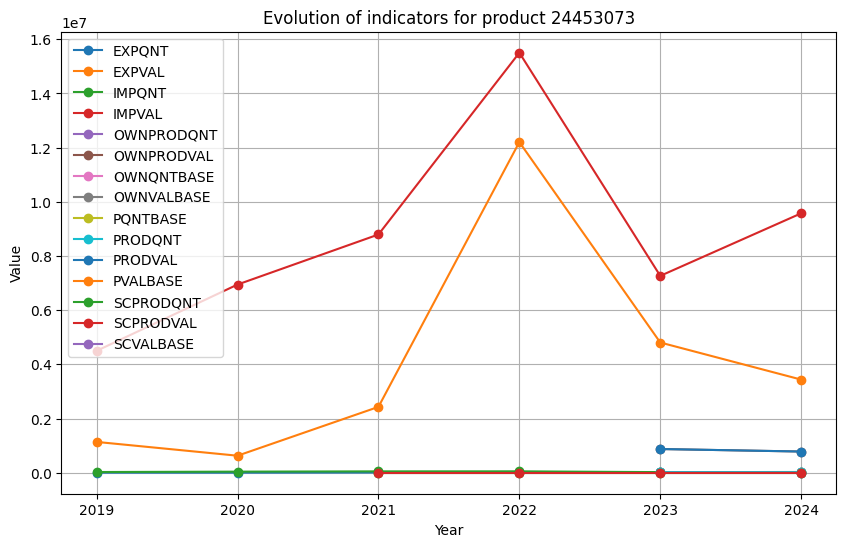

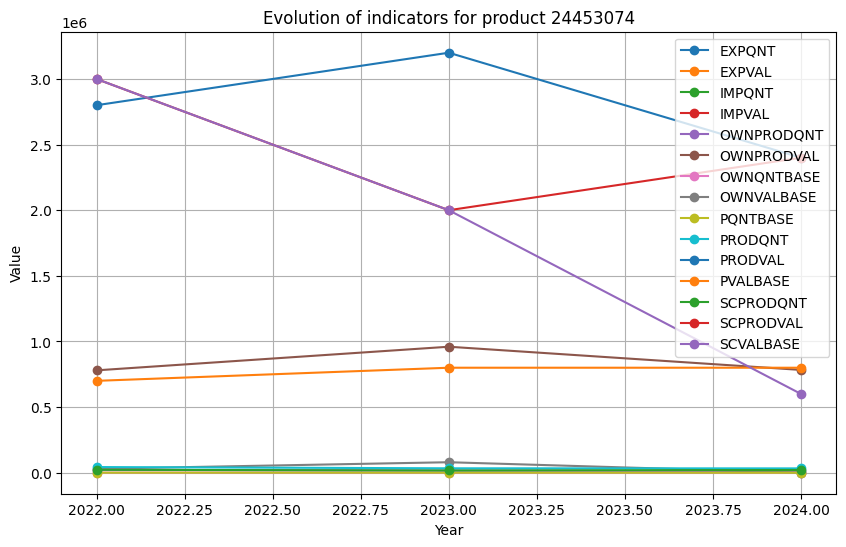

In [11]:
##############################
##### Select gallium data #####
selected_gallium_products = [
'24453073', # Unwrought gallium
'24453074', # Gallium and articles thereof
]
gallium_df = eurostat_df[eurostat_df["product"].isin(selected_gallium_products)].copy()

display(gallium_df)

# Create a dataframe indexed first in "product" and then there should be a row for each year (that should be the index), using the column "TIME_PERIOD" and a column per "indicators" using the "OBS_VALUE" as values
gallium_pivot_df = gallium_df.pivot_table(
    index=["product", "TIME_PERIOD"], 
    columns="indicators", 
    values="OBS_VALUE").reset_index()
display(gallium_pivot_df)

# Make a plot per product showing the evolution of the indicators over time
for product in selected_gallium_products:
    product_data = gallium_pivot_df[gallium_pivot_df["product"] == product]
    plt.figure(figsize=(10, 6))
    for indicator in product_data.columns[2:]: # Skip "product" and "TIME_PERIOD" columns
        plt.plot(product_data["TIME_PERIOD"], product_data[indicator], marker='o', label=indicator)
    plt.title(f"Evolution of indicators for product {product}")
    plt.xlabel("Year")
    plt.ylabel("Value")
    plt.legend()
    plt.grid()
    plt.show()